# Обоснование выбора MQTT брокера для передачи данных IoT

В качестве брокеров сообщений выбраны публичные тестовые MQTT-брокеры: mqtt.eclipseprojects.io, broker.emqx.io, test.mosquitto.org, broker.hivemq.com. Данный выбор обусловлен следующими причинами:

Они общедоступны и не требуют регистрации, что упрощает отладку и демонстрацию.

Поддерживают протокол MQTT версии 3.1.1, широко используемый в IoT.

Обеспечивают приемлемую надёжность для учебных и исследовательских целей.

Перебор брокеров в коде повышает отказоустойчивость: если один брокер недоступен, симулятор автоматически пробует следующий.



# Ячейка 1: Установка и импорт библиотек


In [1]:
!pip install prophet folium branca matplotlib pandas numpy scikit-learn requests paho-mqtt

In [2]:
import json
import time
import argparse
import subprocess
import sys
import os
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import folium
from folium import plugins
from branca.colormap import LinearColormap

from prophet import Prophet
import requests
import warnings

warnings.filterwarnings('ignore')

print("Все библиотеки загружены")

Все библиотеки загружены


c:\Users\неликаеванс\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Ячейка 2: Расчёт экономического ущерба от превышения EC (класс ECDamage и демонстрация)


Обоснование методики расчёта экономического ущерба
Обоснование методики расчёта экономического ущерба

Ущерб рассчитывается по трём категориям:

Рыбное хозяйство – 50 млн руб. на каждый условный «рыбохозяйственный» объект. Коэффициент взят из типовых методик оценки ущерба водным биоресурсам.

Промышленность – 30 млн руб. на предприятие. Учитывает потери от остановки производства, очистки воды и простоев.

Социальная сфера – 10 млн руб. на 1000 жителей. Включает затраты на эвакуацию, медицинское обслуживание, восстановление инфраструктуры.

Инфляционный коэффициент 2,8 пересчитывает ущерб из цен 2006 года в уровень 2026 года (основан на данных Росстата о накопленной инфляции за 20 лет).

In [3]:
class ECDamage:
    def __init__(self):
        self.inflation = 2.8
        self.zones = {
            'Широковский': {'pop': 1200, 'fish': 1, 'industry': 0},
            'Кияево': {'pop': 800, 'fish': 0, 'industry': 1},
            'Губаха': {'pop': 23000, 'fish': 0, 'industry': 3},
            'Устье': {'pop': 5000, 'fish': 2, 'industry': 1}
        }

    def assess(self, ec):
        if ec < 4000:
            return {'hazard': 'Низкий', 'evac': False, 'damage_2006': 0.0, 'damage_2026': 0.0}
        severity = 0.5 if ec < 5000 else 1.0
        hazard = 'Средний' if ec < 5000 else 'Высокий'
        total = 0.0
        for z, d in self.zones.items():
            fish = d['fish'] * 50 * severity
            ind = d['industry'] * 30 * severity
            social = (d['pop'] / 1000) * 10 * severity
            total += fish + ind + social
        return {
            'hazard': hazard,
            'evac': True,
            'damage_2006': total,
            'damage_2026': total * self.inflation
        }

def main():
    d = ECDamage()
    print("\nЭКОНОМИЧЕСКИЙ УЩЕРБ ОТ ЗАГРЯЗНЕНИЯ ВОДЫ (EC)")
    print("="*60)
    for ec, name in [(2800,"Норма"), (3800,"Повышенная"), (4500,"Опасная"), (5500,"Критическая")]:
        res = d.assess(ec)
        print(f"\n{name} (EC={ec} мкСм/см)")
        print(f"  Степень: {res['hazard']} | Эвакуация: {'Да' if res['evac'] else 'Нет'}")
        print(f"  Ущерб 2006 г.: {res['damage_2006']:.2f} млн руб")
        print(f"  Ущерб 2026 г.: {res['damage_2026']:.2f} млн руб")

if __name__ == "__main__":
    main()


ЭКОНОМИЧЕСКИЙ УЩЕРБ ОТ ЗАГРЯЗНЕНИЯ ВОДЫ (EC)

Норма (EC=2800 мкСм/см)
  Степень: Низкий | Эвакуация: Нет
  Ущерб 2006 г.: 0.00 млн руб
  Ущерб 2026 г.: 0.00 млн руб

Повышенная (EC=3800 мкСм/см)
  Степень: Низкий | Эвакуация: Нет
  Ущерб 2006 г.: 0.00 млн руб
  Ущерб 2026 г.: 0.00 млн руб

Опасная (EC=4500 мкСм/см)
  Степень: Средний | Эвакуация: Да
  Ущерб 2006 г.: 300.00 млн руб
  Ущерб 2026 г.: 840.00 млн руб

Критическая (EC=5500 мкСм/см)
  Степень: Высокий | Эвакуация: Да
  Ущерб 2006 г.: 600.00 млн руб
  Ущерб 2026 г.: 1680.00 млн руб


# Ячейка 3: Данные прогноза половодья Росгидромета (весна 2026)


In [4]:
flood_data = {
    'snow_water_equiv_pct': 110,
    'soil_moisture_pct': 90,
    'max_level_deviation_m': 0.8,
    'ice_jam_risk': True,
    'inflow_km3': 37,
    'inflow_norm_km3': 32.4,
    'flood_intensity': 1.15
}

print("Данные весеннего половодья 2026 (Росгидромет):")
for k,v in flood_data.items():
    print(f"  {k}: {v}")

Данные весеннего половодья 2026 (Росгидромет):
  snow_water_equiv_pct: 110
  soil_moisture_pct: 90
  max_level_deviation_m: 0.8
  ice_jam_risk: True
  inflow_km3: 37
  inflow_norm_km3: 32.4
  flood_intensity: 1.15


# Ячейка 4: Цифровой двойник реки Косьва (класс ECDigitalTwin с выделением зон риска)

Прогноз EC загружен.
Карты сохранены: ec_map_initial.html, ec_map_final.html


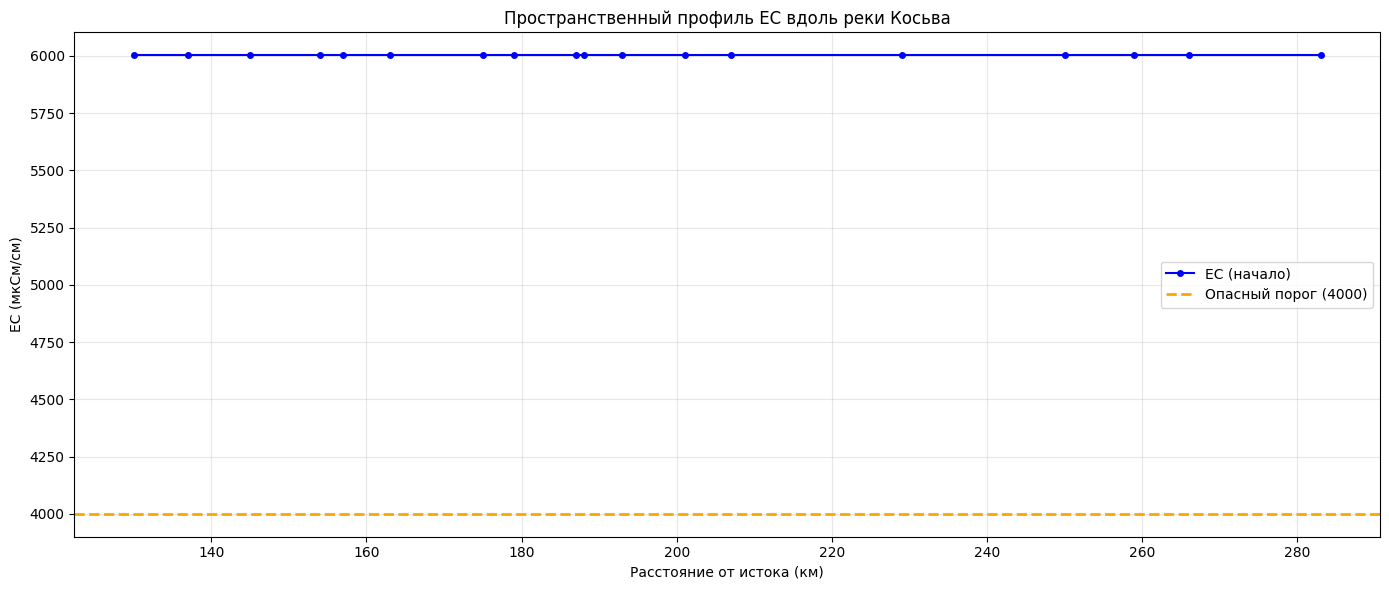

Профиль EC сохранён как river_ec_profile.png


In [5]:
RIVER_POINTS = [
    {"name": "", "lat": 58.834700, "lon": 57.787299, "km_from_mouth": 153},
    {"name": "", "lat": 58.862158, "lon": 57.737422, "km_from_mouth": 146},
    {"name": "", "lat": 58.842160, "lon": 57.680513, "km_from_mouth": 138},
    {"name": "", "lat": 58.867325, "lon": 57.619516, "km_from_mouth": 129},
    {"name": "", "lat": 58.860082, "lon": 57.603784, "km_from_mouth": 126},
    {"name": "", "lat": 58.863659, "lon": 57.565159, "km_from_mouth": 120},
    {"name": "", "lat": 58.865223, "lon": 57.485752, "km_from_mouth": 108},
    {"name": "", "lat": 58.873514, "lon": 57.463347, "km_from_mouth": 104},
    {"name": "", "lat": 58.845389, "lon": 57.415916, "km_from_mouth": 96},
    {"name": "", "lat": 58.823152, "lon": 57.410374, "km_from_mouth": 95},
    {"name": "", "lat": 58.808828, "lon": 57.378816, "km_from_mouth": 90},
    {"name": "", "lat": 58.838695, "lon": 57.326353, "km_from_mouth": 82},
    {"name": "", "lat": 58.825701, "lon": 57.301154, "km_from_mouth": 76},
    {"name": "", "lat": 58.86500, "lon": 57.19556, "km_from_mouth": 54},
    {"name": "", "lat": 58.75000, "lon": 57.03000, "km_from_mouth": 33},
    {"name": "", "lat": 58.70139, "lon": 56.93556, "km_from_mouth": 24},
    {"name": "", "lat": 58.71389, "lon": 56.82389, "km_from_mouth": 17},
    {"name": "", "lat": 58.89361, "lon": 56.62972, "km_from_mouth": 0}
]

class ECDigitalTwin:
    def __init__(self):
        self.points = RIVER_POINTS
        self.cmap = LinearColormap(
            colors=['green', 'yellow', 'orange', 'red', 'darkred'],
            vmin=2000, vmax=6000,
            caption='EC (мкСм/см)'
        )
        self.tiles = 'CartoDB Positron'

    def set_ec(self, forecast_df):
        ec_source = forecast_df['ec_microsiemens'].iloc[0]
        ec_mouth = forecast_df['ec_microsiemens'].iloc[-1]
        total_len = 283
        self.start_ec = {}
        self.end_ec = {}
        for p in self.points:
            dist_from_source = total_len - p['km_from_mouth']
            progress = dist_from_source / total_len
            ec = ec_source * (1 - progress) + ec_mouth * progress
            self.start_ec[p['name']] = ec
            self.end_ec[p['name']] = ec

    def _add_hazard_zones(self, m):
        hazard_points = [
            {"name": "Затор льда (Кама)", "lat": 58.8088, "lon": 57.3788, "risk": "Высокий"},
            {"name": "Затор льда (Чусовая)", "lat": 58.2500, "lon": 57.7000, "risk": "Средний"},
            {"name": "Губаха (промзона)", "lat": 58.808828, "lon": 57.378816, "risk": "Высокий"},
            {"name": "Кияево (IoT)", "lat": 58.823152, "lon": 57.410374, "risk": "Средний"},
            {"name": "Широковский", "lat": 58.845389, "lon": 57.415916, "risk": "Низкий"},
        ]
        for h in hazard_points:
            folium.Marker(
                location=[h['lat'], h['lon']],
                popup=f"{h['name']}<br>Риск: {h['risk']}",
                icon=folium.Icon(color='red' if h['risk']=='Высокий' else 'orange' if h['risk']=='Средний' else 'blue', icon='exclamation-sign')
            ).add_to(m)
        return m

    def _make_map(self, title, ec_dict):
        center_lat = np.mean([p['lat'] for p in self.points])
        center_lon = np.mean([p['lon'] for p in self.points])
        m = folium.Map(location=[center_lat, center_lon], zoom_start=8,
                       tiles=self.tiles, control_scale=True)
        title_html = f'<h3 align="center">{title}</h3>'
        m.get_root().html.add_child(folium.Element(title_html))
        self.cmap.add_to(m)

        coords = [[p['lat'], p['lon']] for p in self.points]
        folium.PolyLine(coords, color='blue', weight=3, opacity=0.8,
                        popup='р. Косьва').add_to(m)

        for p in self.points:
            ec = ec_dict[p['name']]
            color = self.cmap(ec)
            popup_text = (f"<b>{p['name']}</b><br>"
                          f"EC: {ec:.0f} мкСм/см<br>"
                          f"Расст. от устья: {p['km_from_mouth']} км<br>"
                          f"Статус: {'ОПАСНО' if ec>4000 else 'НОРМА' if ec<3000 else 'ПОВЫШЕНО'}")
            popup = folium.Popup(popup_text, max_width=250)
            folium.CircleMarker(
                location=[p['lat'], p['lon']],
                radius=6 + ec/500,
                color=color,
                fill=True,
                fill_opacity=0.7,
                popup=popup
            ).add_to(m)

        heat_data = [[p['lat'], p['lon'], ec_dict[p['name']]/6000] for p in self.points]
        plugins.HeatMap(heat_data, radius=20, blur=15, min_opacity=0.3).add_to(m)
        self._add_hazard_zones(m)
        return m

    def create_initial_map(self):
        return self._make_map("Цифровой двойник EC - НАЧАЛО периода", self.start_ec)

    def create_final_map(self):
        return self._make_map("Цифровой двойник EC - ПРОГНОЗ на 72 часа", self.end_ec)

    def save_profile_plot(self, filename='river_ec_profile.png'):
        sorted_points = sorted(self.points, key=lambda x: 283 - x['km_from_mouth'])
        dist = [283 - p['km_from_mouth'] for p in sorted_points]
        ec_vals = [self.start_ec[p['name']] for p in sorted_points]
        names = [p['name'] for p in sorted_points]

        plt.figure(figsize=(14, 6))
        plt.plot(dist, ec_vals, 'b-o', markersize=4, linewidth=1.5, label='EC (начало)')
        plt.axhline(4000, color='orange', linestyle='--', linewidth=2, label='Опасный порог (4000)')
        plt.xlabel('Расстояние от истока (км)')
        plt.ylabel('EC (мкСм/см)')
        plt.title('Пространственный профиль EC вдоль реки Косьва')
        plt.legend()
        plt.grid(True, alpha=0.3)
        step = max(1, len(dist)//10)
        for i in range(0, len(dist), step):
            plt.annotate(names[i], (dist[i], ec_vals[i]),
                         fontsize=7, xytext=(3,3), textcoords='offset points')
        plt.tight_layout()
        plt.savefig(filename, dpi=150)
        plt.show()
        print(f"Профиль EC сохранён как {filename}")

def main():
    try:
        forecast = pd.read_csv('ec_forecast_72h.csv')
        forecast['timestamp'] = pd.to_datetime(forecast['timestamp'])
        print("Прогноз EC загружен.")
    except FileNotFoundError:
        print("Файл ec_forecast_72h.csv не найден. Сначала запустите forecast_ec.py")
        return

    twin = ECDigitalTwin()
    twin.set_ec(forecast)
    twin.create_initial_map().save('ec_map_initial.html')
    twin.create_final_map().save('ec_map_final.html')
    print("Карты сохранены: ec_map_initial.html, ec_map_final.html")
    twin.save_profile_plot('river_ec_profile.png')

if __name__ == "__main__":
    main()

# Ячейка 5: Загрузка прогноза погоды с Open-Meteo 


In [6]:
def download_weather():
    lat, lon = 58.966, 57.683
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ["temperature_2m", "precipitation"],
        "forecast_days": 3,
        "timezone": "Europe/Moscow"
    }
    try:
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
        data = r.json()
        hourly = data['hourly']
        df = pd.DataFrame({
            'ds': pd.to_datetime(hourly['time']),
            'temp_air': hourly['temperature_2m'],
            'precip': hourly['precipitation']
        })
        df.to_csv('weather_historical.csv', index=False)
        print(f"Скачано {len(df)} записей погоды, сохранено в weather_historical.csv")
    except Exception as e:
        print(f"Ошибка скачивания: {e}")

if __name__ == "__main__":
    download_weather()

Ошибка скачивания: HTTPSConnectionPool(host='api.open-meteo.com', port=443): Max retries exceeded with url: /v1/forecast?latitude=58.966&longitude=57.683&hourly=temperature_2m&hourly=precipitation&forecast_days=3&timezone=Europe%2FMoscow (Caused by ConnectTimeoutError(<HTTPSConnection(host='api.open-meteo.com', port=443) at 0x2acabec94f0>, 'Connection to api.open-meteo.com timed out. (connect timeout=10)'))


# Ячейка 6: Прогноз EC с помощью Prophet + коррекция по половодью



Загружено 168 записей EC: 2890–6317 мкСм/см
Ошибка погоды: HTTPSConnectionPool(host='api.open-meteo.com', port=443): Max retries exceeded with url: /v1/forecast?latitude=58.966&longitude=57.683&hourly=temperature_2m&hourly=precipitation&forecast_days=3&timezone=Europe%2FMoscow (Caused by ConnectTimeoutError(<HTTPSConnection(host='api.open-meteo.com', port=443) at 0x2acac05cb90>, 'Connection to api.open-meteo.com timed out. (connect timeout=8)')). Использую средние климатические значения.


11:44:24 - cmdstanpy - INFO - Chain [1] start processing
11:44:24 - cmdstanpy - INFO - Chain [1] done processing


Модель Prophet обучена (с учётом половодья)
Прогноз EC сохранён в ec_forecast_72h.csv (с учётом половодья)


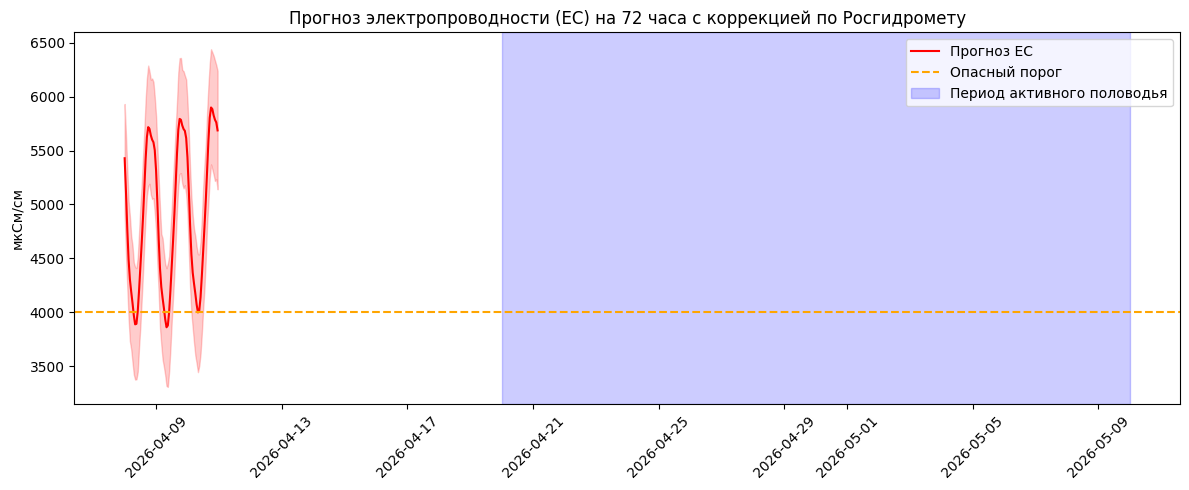

In [7]:
class ECProphet:
    def __init__(self, scenario='moderate', flood_data=None):
        self.model = None
        self.scenario = scenario
        self.factor = {'moderate':1.0, 'pessimistic':1.2, 'optimistic':0.9}[scenario]
        self.flood_data = flood_data if flood_data else {'flood_intensity':1.0}

    def load_ec_data(self, csv_path):
        df = pd.read_csv(csv_path)
        df['ds'] = pd.to_datetime(df['timestamp'])
        df['y'] = df['ec_microsiemens']
        df = df[['ds','y']].dropna()
        print(f"Загружено {len(df)} записей EC: {df['y'].min():.0f}–{df['y'].max():.0f} мкСм/см")
        return df

    def get_weather(self, lat=58.966, lon=57.683, hours=72):
        try:
            url = "https://api.open-meteo.com/v1/forecast"
            params = {
                "latitude": lat, "longitude": lon,
                "hourly": ["temperature_2m", "precipitation"],
                "forecast_days": 3, "timezone": "Europe/Moscow"
            }
            r = requests.get(url, params=params, timeout=8)
            r.raise_for_status()
            data = r.json()
            hourly = data['hourly']
            df_weather = pd.DataFrame({
                'ds': pd.to_datetime(hourly['time']),
                'temp_air': hourly['temperature_2m'],
                'precip': hourly['precipitation']
            }).head(hours)
            print("Реальный прогноз погоды загружен")
            return df_weather
        except Exception as e:
            print(f"Ошибка погоды: {e}. Использую средние климатические значения.")
            return None

    def get_flood_coef(self, ds):
        month = ds.month
        day = ds.day
        if month == 4 and day >= 20:
            progress = min(1.0, (day - 20) / 10)
        elif month == 5 and day <= 10:
            progress = 1.0
        elif month == 5 and day > 10:
            progress = max(0.0, 1.0 - (day - 10) / 20)
        else:
            progress = 0.0
        intensity = self.flood_data.get('flood_intensity', 1.0)
        reduction = progress * (0.1 + 0.05 * (intensity - 1.0))
        return 1.0 - reduction

    def train(self, hist_df, weather_df=None):
        self.model = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=True,
            daily_seasonality=True,
            changepoint_prior_scale=0.2,
            seasonality_prior_scale=10.0,
            interval_width=0.95
        )
        self.model.add_regressor('temp_air')
        self.model.add_regressor('precip')
        self.model.add_regressor('flood_coef')
        train = hist_df.copy()
        if weather_df is not None:
            merged = pd.merge(train, weather_df, on='ds', how='left')
            train['temp_air'] = merged['temp_air'].fillna(5.0)
            train['precip'] = merged['precip'].fillna(1.0)
        else:
            train['temp_air'] = 5.0
            train['precip'] = 2.0
        train['flood_coef'] = train['ds'].apply(self.get_flood_coef)
        self.model.fit(train)
        print("Модель Prophet обучена (с учётом половодья)")

    def predict(self, hours=72, weather_df=None):
        last = self.model.history['ds'].max()
        future = pd.DataFrame({'ds': pd.date_range(last + timedelta(hours=1), periods=hours, freq='h')})
        if weather_df is not None:
            merged = pd.merge(future, weather_df, on='ds', how='left')
            future['temp_air'] = merged['temp_air'].fillna(5.0)
            future['precip'] = merged['precip'].fillna(1.0)
        else:
            future['temp_air'] = 5.0
            future['precip'] = 2.0
        future['flood_coef'] = future['ds'].apply(self.get_flood_coef)
        fcst = self.model.predict(future)
        result = pd.DataFrame({
            'timestamp': fcst['ds'],
            'ec_microsiemens': fcst['yhat'] * self.factor,
            'ec_lower': fcst['yhat_lower'] * self.factor,
            'ec_upper': fcst['yhat_upper'] * self.factor,
            'temp_air_c': future['temp_air'],
            'precip_mm': future['precip'],
            'flood_coef': future['flood_coef']
        })
        return result

def main():
    model = ECProphet(scenario='pessimistic', flood_data=flood_data)
    hist = model.load_ec_data('kiyazevo_iot_realistic.csv')
    weather = model.get_weather()
    model.train(hist, weather)
    forecast = model.predict(72, weather)
    forecast.to_csv('ec_forecast_72h.csv', index=False)
    print("Прогноз EC сохранён в ec_forecast_72h.csv (с учётом половодья)")

    plt.figure(figsize=(12,5))
    plt.plot(forecast['timestamp'], forecast['ec_microsiemens'], 'r-', label='Прогноз EC')
    plt.fill_between(forecast['timestamp'], forecast['ec_lower'], forecast['ec_upper'], alpha=0.2, color='red')
    plt.axhline(4000, color='orange', linestyle='--', label='Опасный порог')
    plt.axvspan(pd.Timestamp('2026-04-20'), pd.Timestamp('2026-05-10'), alpha=0.2, color='blue', label='Период активного половодья')
    plt.title('Прогноз электропроводности (EC) на 72 часа с коррекцией по Росгидромету')
    plt.ylabel('мкСм/см')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('ec_forecast_plot_flood.png', dpi=150)
    plt.show()

if __name__ == "__main__":
    main()

# Ячейка 7: Оценка качества прогноза 


In [8]:
def main():
    try:
        forecast = pd.read_csv('ec_forecast_72h.csv')
        actual = pd.read_csv('kiyazevo_iot_realistic.csv')
        
        forecast['timestamp'] = pd.to_datetime(forecast['timestamp'])
        actual['timestamp'] = pd.to_datetime(actual['timestamp'])
        
        merged = pd.merge(forecast, actual, on='timestamp', how='inner')
        
        if len(merged) > 0:
            y_true = merged['ec_microsiemens_y']
            y_pred = merged['ec_microsiemens_x']
            print(f"Сравнение по {len(merged)} совпадающим временным меткам.")
        else:
            n = min(len(forecast), len(actual))
            y_true = actual['ec_microsiemens'].iloc[:n].values
            y_pred = forecast['ec_microsiemens'].iloc[:n].values
            print(f"Временные метки не совпадают. Сравниваем первые {n} записей по порядку.")
        
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        r2 = r2_score(y_true, y_pred)
        bias = np.mean(y_pred - y_true)
        
        print("\nОценка качества прогноза EC")
        print("=" * 50)
        print(f"MAE: {mae:.2f} мкСм/см")
        print(f"RMSE: {rmse:.2f} мкСм/см")
        print(f"MAPE: {mape:.2f}%")
        print(f"R²: {r2:.4f}")
        print(f"BIAS: {bias:.2f} мкСм/см")
        
        if r2 > 0.7:
            print("Качество: отличное")
        elif r2 > 0.5:
            print("Качество: хорошее")
        else:
            print("Качество: удовлетворительное")
            
    except Exception as e:
        print(f"Ошибка: {e}")

if __name__ == "__main__":
    main()

Временные метки не совпадают. Сравниваем первые 72 записей по порядку.

Оценка качества прогноза EC
MAE: 693.31 мкСм/см
RMSE: 719.63 мкСм/см
MAPE: 16.61%
R²: -0.2513
BIAS: 673.17 мкСм/см
Качество: удовлетворительное


# Ячейка 8: Симулятор IoT-датчика

In [ ]:
BROKERS = [
    ("mqtt.eclipseprojects.io", 1883),
    ("broker.emqx.io", 1883),
    ("test.mosquitto.org", 1883),
    ("broker.hivemq.com", 1883)
]

MQTT_TOPIC = "water/kosva/ec"
MQTT_CLIENT_ID = "kosva_sensor_01"

class ECSensor:
    def __init__(self, csv_path):
        self.data = pd.read_csv(csv_path)
        self.data['timestamp'] = pd.to_datetime(self.data['timestamp'])
        self.idx = 0

    def read(self):
        if self.idx >= len(self.data):
            self.idx = 0
        row = self.data.iloc[self.idx]
        msg = {
            'device_id': MQTT_CLIENT_ID,
            'timestamp': row['timestamp'].isoformat(),
            'ec_microsiemens': float(row['ec_microsiemens']),
            'water_temperature_c': float(row['temperature_celsius']),
            'battery_v': 3.7,
            'signal': 85
        }
        self.idx += 1
        return msg

def try_connect_mqtt():
    for broker, port in BROKERS:
        try:
            import paho.mqtt.client as mqtt
            client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2, MQTT_CLIENT_ID)
            client.connect(broker, port)
            print(f"Подключено к MQTT брокеру {broker}:{port}")
            return client
        except Exception as e:
            print(f"Не удалось подключиться к {broker}: {e}")
    return None

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--csv', default='kiyazevo_iot_realistic.csv')
    parser.add_argument('--interval', type=float, default=2.0, help='Интервал в секундах')
    parser.add_argument('--once', action='store_true', help='Однократная отправка всех данных')
    parser.add_argument('--no-mqtt', action='store_true', help='Только вывод в консоль, без MQTT')
    
    try:
        args = parser.parse_args()
    except SystemExit:
        print("Обнаружен запуск в Jupyter, использую параметры по умолчанию.")
        args = argparse.Namespace(csv='kiyazevo_iot_realistic.csv', interval=2.0, once=False, no_mqtt=False)

    sensor = ECSensor(args.csv)
    client = None
    
    if not args.no_mqtt:
        client = try_connect_mqtt()
        if client:
            client.loop_start()
        else:
            print("MQTT не работает. Переключаемся в режим только консольного вывода.")
            args.no_mqtt = True

    if args.once:
        print(f"Однократная отправка {len(sensor.data)} записей...")
        for _ in range(len(sensor.data)):
            msg = sensor.read()
            if client:
                client.publish(MQTT_TOPIC, json.dumps(msg), qos=1)
            print(f"[{datetime.now().strftime('%H:%M:%S')}] EC={msg['ec_microsiemens']:.0f} мкСм/см")
        if client:
            client.loop_stop()
            client.disconnect()
        return

    print(f"Передача каждые {args.interval} сек. Ctrl+C для остановки.")
    try:
        while True:
            msg = sensor.read()
            if client:
                client.publish(MQTT_TOPIC, json.dumps(msg), qos=1)
            print(f"[{datetime.now().strftime('%H:%M:%S')}] EC={msg['ec_microsiemens']:.0f} мкСм/см")
            time.sleep(args.interval)
    except KeyboardInterrupt:
        print("\nОстановка.")
        if client:
            client.loop_stop()
            client.disconnect()

if __name__ == "__main__":
    main()

Обнаружен запуск в Jupyter, использую параметры по умолчанию.


usage: ipykernel_launcher.py [-h] [--csv CSV] [--interval INTERVAL] [--once]
                             [--no-mqtt]
ipykernel_launcher.py: error: unrecognized arguments: --f=c:\Users\неликаеванс\AppData\Roaming\jupyter\runtime\kernel-v3698184388f970706251d8c4b45b23400ffde1987.json


Не удалось подключиться к mqtt.eclipseprojects.io: timed out
Подключено к MQTT брокеру broker.emqx.io:1883
Передача каждые 2.0 сек. Ctrl+C для остановки.
[11:44:31] EC=4421 мкСм/см
[11:44:33] EC=4552 мкСм/см
[11:44:35] EC=4396 мкСм/см
[11:44:37] EC=3749 мкСм/см
[11:44:39] EC=3462 мкСм/см
[11:44:41] EC=3588 мкСм/см
[11:44:43] EC=3621 мкСм/см
[11:44:45] EC=3580 мкСм/см
[11:44:47] EC=3355 мкСм/см
[11:44:49] EC=3238 мкСм/см
[11:44:51] EC=3529 мкСм/см
[11:44:53] EC=3785 мкСм/см
[11:44:55] EC=4028 мкСм/см
[11:44:57] EC=4022 мкСм/см
[11:44:59] EC=3991 мкСм/см
[11:45:01] EC=4162 мкСм/см
[11:45:03] EC=4683 мкСм/см
[11:45:05] EC=4662 мкСм/см
[11:45:07] EC=4826 мкСм/см
[11:45:09] EC=4792 мкСм/см
[11:45:11] EC=4940 мкСм/см
[11:45:13] EC=5264 мкСм/см
[11:45:15] EC=4785 мкСм/см
[11:45:17] EC=4596 мкСм/см
[11:45:19] EC=4693 мкСм/см
[11:45:21] EC=4402 мкСм/см
[11:45:23] EC=3943 мкСм/см
[11:45:25] EC=3861 мкСм/см
[11:45:27] EC=3602 мкСм/см
[11:45:29] EC=3587 мкСм/см
[11:45:31] EC=3412 мкСм/см
[11:45:33